# VOICED Dataset Analysis
## Phase 1: Environment Setup & Data Loading
This notebook will guide you step-by-step through machine learning on physiological datasets using your MacBook Pro M4.

In [1]:
# Run this cell to ensure packages are installed in the current Jupyter Kernel
!pip install --quiet --upgrade pip wfdb librosa scikit-learn pandas matplotlib jupyter imbalanced-learn

In [3]:
import os
import platform
import wfdb
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Check system architecture for Apple Silicon compatibility
print(f"System: {platform.system()} {platform.release()}")
print(f"Architecture: {platform.machine()}")
print(f"Python Version: {platform.python_version()}")

System: Darwin 25.3.0
Architecture: arm64
Python Version: 3.13.7


### Step 1.1: Test Loading the Data
We use `wfdb` (Waveform Database) to read the PhysioNet format files.

Successfully loaded voice001!
Sampling Frequency: 8000 Hz
Signal Duration: 4.76 seconds


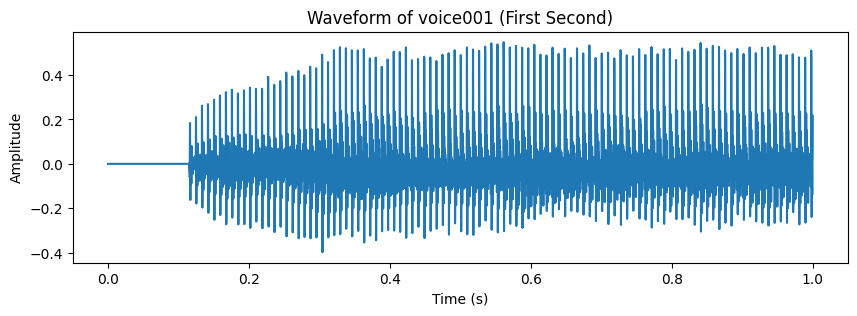

In [5]:
data_dir = "voice-icar-federico-ii-database-1.0.0"
test_record = "voice001"
record_path = os.path.join(data_dir, test_record)

try:
    # Load signal and metadata
    record = wfdb.rdrecord(record_path)
    
    # Extract signal and sampling frequency
    audio_signal = record.p_signal[:, 0]
    fs = record.fs
    
    print(f"Successfully loaded {test_record}!")
    print(f"Sampling Frequency: {fs} Hz")
    print(f"Signal Duration: {len(audio_signal) / fs:.2f} seconds")

    # Plot the first second of the audio signal
    time_axis = np.arange(len(audio_signal)) / fs
    plt.figure(figsize=(10, 3))
    plt.plot(time_axis[:fs], audio_signal[:fs]) # Plot first second
    plt.title(f"Waveform of {test_record} (First Second)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()
    
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Make sure the data directory is correct and files are downloaded.")

### Phase 2: Data Exploration & Preprocessing

**Step 2.1: Loading all Metadata**
Now that we know the audio signals load perfectly, we need to gather all the text data (metadata) for all 208 patients. 
The code below iterates through all the `-info.txt` files, extracts key details (Age, Gender, Diagnosis, Smoker status), and compiles them into a structured Pandas `DataFrame` (a 2D table like an Excel spreadsheet).

In [6]:
import glob

metadata_list = []
info_files = sorted(glob.glob(os.path.join(data_dir, "*-info.txt")))

# Loop through all 208 text files containing metadata
for file_path in info_files:
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
        
    # Dictionary to store this specific patient's data
    patient_data = {'ID': os.path.basename(file_path).replace('-info.txt', '')}
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        # Files are somewhat inconsistently formatted, we split by colon or tab
        if ':' in line:
            parts = line.split(':', 1)
        elif '\t' in line:
            parts = line.split('\t', 1)
        else:
            continue
            
        if len(parts) == 2:
            key = parts[0].strip()
            val = parts[1].strip()
            
            # Extract just the core features we care about for now
            if key in ['Age', 'Gender', 'Diagnosis', 'Smoker', 'Voice Handicap Index (VHI) Score', 'Reflux Symptom Index (RSI) Score']:
                patient_data[key] = val
                
    metadata_list.append(patient_data)

# Create a Pandas DataFrame (like an Excel table)
df_meta = pd.DataFrame(metadata_list)

# Clean up 'NU' (meaning Not Used / Null) to standard pandas NaN (Not a Number)
df_meta.replace('NU', np.nan, inplace=True)
df_meta['Age'] = pd.to_numeric(df_meta['Age'], errors='coerce')
df_meta['Voice Handicap Index (VHI) Score'] = pd.to_numeric(df_meta['Voice Handicap Index (VHI) Score'], errors='coerce')

# Print out the distribution of Diagnoses to see how imbalanced the dataset is
print("Diagnosis Distribution:")
print(df_meta['Diagnosis'].value_counts(dropna=False))

# Create our Machine Learning target label: 0 for healthy, 1 for pathological
df_meta['Label'] = df_meta['Diagnosis'].apply(lambda x: 0 if str(x).lower().strip() == 'healthy' else 1)

print(f"\nTotal records processed: {len(df_meta)}")
# Display the first 5 rows to verify it worked
df_meta.head()

Diagnosis Distribution:
Diagnosis
healthy                                                57
hyperkinetic dysphonia                                 43
reflux laryngitis                                      38
hypokinetic dysphonia                                  22
hyperkinetic dysphonia (Prolapse)                       9
hypokinetic dysphonia (glottic insufficiency)           6
hyperkinetic dysphonia (Polyps)                         5
hypokinetic dysphonia (Vocal fold paralysis)            4
hyperkinetic dysphonia (nodule)                         3
hyperkinetic dysphonia (Reinke's edema)                 3
hyperkinetic dysphonia (Nodule)                         2
hyperkinetic dysphonia (Cordite)                        1
hypokinetic dysphonia (Spasmodic dysphonia)             1
hypokinetic dysphonia (Conversion dysphonia)            1
hyperkinetic dysphonia (Vocal fold prolapse)            1
hypokinetic dysphonia (Dysphonia by chordal groove)     1
hyperkinetic dysphonia (polyps)       

,ID,Age,Gender,Diagnosis,Voice Handicap Index (VHI) Score,Reflux Symptom Index (RSI) Score,Smoker,Label
0,voice001,32,m,hyperkinetic dysphonia,15,5,no,1
1,voice002,55,m,healthy,17,12,casual smoker,0
2,voice003,34,m,hyperkinetic dysphonia (nodule),42,26,no,1
3,voice004,28,f,hypokinetic dysphonia,20,9,casual smoker,1
4,voice005,54,f,hypokinetic dysphonia,39,23,no,1


**Step 2.2: Extracting Audio Features (The Core of Machine Learning)**
Machine learning algorithms cannot easily understand raw audio waveforms (a long string of numbers). Instead, we need to extract **features**—mathematical representations of the sound. 
We will use the `librosa` library to extract features like **MFCCs** (Mel-Frequency Cepstral Coefficients), which are standard in voice and speech analysis because they represent how human ears perceive frequency.

In [7]:
def extract_features(record_id, data_dir):
    """
    Given a record ID (like 'voice001'), this loads the raw audio and 
    extracts key statistical features for our machine learning model.
    """
    record_path = os.path.join(data_dir, record_id)
    try:
        record = wfdb.rdrecord(record_path)
        y = record.p_signal[:, 0]
        sr = record.fs
        
        # 1. Extract 13 MFCCs (Mel-Frequency Cepstral Coefficients)
        # We take the mean across the entire 5-second time dimension to get a single number per coefficient
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfccs_mean = np.mean(mfccs, axis=1)
        
        # 2. Spectral Centroid (Indicates where the "center of mass" of the spectrum is)
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        centroid_mean = np.mean(centroid)
        
        # 3. Spectral Bandwidth (Indicates the range of frequencies)
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        bandwidth_mean = np.mean(bandwidth)

        # 4. Zero Crossing Rate (How often signal changes sign, good for noise detection)
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)

        # Store all these numbers in a dictionary
        features = {
            'ID': record_id,
            'centroid_mean': centroid_mean,
            'bandwidth_mean': bandwidth_mean,
            'zcr_mean': zcr_mean
        }
        
        # Add the 13 MFCCs to the dictionary
        for i in range(13):
            features[f'mfcc_{i+1}'] = mfccs_mean[i]
            
        return features
    except Exception as e:
        print(f"Error processing {record_id}: {e}")
        return None

print("Starting feature extraction... (this takes a few seconds)")

# Run extraction on all patients
all_features = []
for index, row in df_meta.iterrows():
    f = extract_features(row['ID'], data_dir)
    if f:
        all_features.append(f)

# Convert features into a DataFrame
df_features = pd.DataFrame(all_features)

# Combine the Metadata and the Audio Features into one final Master dataset
df_final = pd.merge(df_meta, df_features, on='ID')

print(f"Extraction complete! Final dataset structure: {df_final.shape[0]} rows x {df_final.shape[1]} columns")
# Preview the first few rows
df_final.head()

Starting feature extraction... (this takes a few seconds)
Extraction complete! Final dataset structure: 208 rows x 24 columns


,ID,Age,Gender,Diagnosis,Voice Handicap Index (VHI) Score,Reflux Symptom Index (RSI) Score,Smoker,Label,centroid_mean,bandwidth_mean,...,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,voice001,32,m,hyperkinetic dysphonia,15,5,no,1,1163.557195,731.097656,...,-16.300682,-6.631975,17.999434,-27.778969,15.623700,6.169481,-34.712455,-3.559567,-6.395851,-8.561320
1,voice002,55,m,healthy,17,12,casual smoker,0,1010.746722,682.710330,...,-33.146484,-15.068009,3.447450,-22.321822,10.138316,13.726444,-27.952345,-21.330649,-14.298918,-6.626558
2,voice003,34,m,hyperkinetic dysphonia (nodule),42,26,no,1,1394.785976,943.542145,...,-35.288694,3.767250,5.081971,-20.880665,13.056897,-4.589232,-28.704122,-10.099688,-0.145197,-10.543688
3,voice004,28,f,hypokinetic dysphonia,20,9,casual smoker,1,1352.934113,967.504043,...,32.183496,19.796031,-24.004164,11.081125,4.832909,-22.760615,-3.648753,-25.758860,-8.976304,-23.258990
4,voice005,54,f,hypokinetic dysphonia,39,23,no,1,1313.607576,876.681753,...,-17.298141,28.267973,4.029834,-3.836589,-4.155939,-23.870635,1.722772,-17.541468,-1.895349,-22.703729


### Phase 3: Supervised Learning (Problem #1)

Now that we have our features (the X variables) and our labels (the Y variable: 0 for healthy, 1 for pathological), we can train machine learning models. 

**Step 3.1: Data Splitting and Scaling**
Before training, we must:
1. Divide our data: 80% to "teach" the model (Training set) and 20% to "test" the model (Testing set). 
2. Scale the data: The features have vastly different numerical ranges (e.g., ZCR is a tiny decimal, while Centroid is a large number). We use a `StandardScaler` to put them all on a level playing field so the algorithm doesn't get confused.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Define what features we want the models to learn from
# We drop the non-numeric metadata strings for now and focus purely on the Audio features and numeric scores
feature_columns = [col for col in df_final.columns if col not in ['ID', 'Gender', 'Diagnosis', 'Smoker', 'Label']]

# X contains all our math features
# y contains our target: 0 (Healthy) or 1 (Pathological)
X = df_final[feature_columns]

# Ensure everything in X is treated as a number. Some metadata scores might still be saved as text strings.
# Coerce errors to NaN, then we can safely fill them with the median.
X = X.apply(pd.to_numeric, errors='coerce')

# Fill any missing metadata values (like Missing Age) with the median of that column
X = X.fillna(X.median()) 

y = df_final['Label']

# Split the dataset: 80% for training, 20% for testing
# stratify=y ensures we keep the same ratio of healthy/pathological in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to handle class imbalance on the training data ONLY
smote = SMOTE(random_state=42)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

print(f"Training dataset size (after SMOTE): {X_train_scaled.shape[0]} people")
print(f"Testing dataset size: {X_test_scaled.shape[0]} people")
print(f"Number of distinct features being analyzed: {X_train_scaled.shape[1]}")

Training dataset size (after SMOTE): 242 people
Testing dataset size: 42 people
Number of distinct features being analyzed: 19


**Step 3.2: Training 5 Different Machine Learning Models**
The assignment asks us to compare 5 different models. We will train:
1. **Logistic Regression:** A great, simple baseline model.
2. **Support Vector Machine (SVM):** Excellent for small datasets with complex boundaries.
3. **Random Forest:** An ensemble of many "Decision Trees" voting together.
4. **K-Nearest Neighbors (KNN):** Looks at the 5 most similar patients and guesses based on them.
5. **Multi-Layer Perceptron (MLP):** A classic neural network.

We will write a loop to train all 5 at once and print out their critical performance metrics: **Accuracy, Sensitivity, Specificity, and F1-Score**.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

# Initialize our 5 models
# Added class_weight='balanced' to handle class imbalance and improve Specificity
models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced'),
    "Support Vector Machine (SVM)": SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5), # KNN does not support class_weight natively
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42) # MLP does not support class_weight natively
}

# Dictionary to store results for later comparison/plotting
results = {}

print("--- MODEL EVALUATION RESULTS ---\n")

for name, model in models.items():
    # 1. Train the model using the 80% training data
    model.fit(X_train_scaled, y_train)
    
    # 2. Ask the model to guess the diagnoses of the 20% unseen test data
    y_pred = model.predict(X_test_scaled)
    
    # 3. Calculate metrics by comparing the model's guesses (y_pred) to the actual real answers (y_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Confusion matrix returns: True Negative, False Positive, False Negative, True Positive
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0   # Also known as Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 
    
    # f1_score computation
    _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
    
    # Save the results
    results[name] = {
        'Accuracy': acc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'F1-Score': f1
    }
    
    print(f"Model: {name}")
    print(f"  Accuracy:    {acc:.2f}")
    print(f"  Sensitivity: {sensitivity:.2f} (How well it finds true diseased patients)")
    print(f"  Specificity: {specificity:.2f} (How well it identifies true healthy patients)")
    print(f"  F1-Score:    {f1:.2f}")
    print("-" * 30)

# Display a nice summary table
pd.DataFrame(results).T

--- MODEL EVALUATION RESULTS ---

Model: Logistic Regression
  Accuracy:    0.67
  Sensitivity: 0.70 (How well it finds true diseased patients)
  Specificity: 0.58 (How well it identifies true healthy patients)
  F1-Score:    0.75
------------------------------
Model: Support Vector Machine (SVM)
  Accuracy:    0.69
  Sensitivity: 0.83 (How well it finds true diseased patients)
  Specificity: 0.33 (How well it identifies true healthy patients)
  F1-Score:    0.79
------------------------------
Model: Random Forest
  Accuracy:    0.62
  Sensitivity: 0.70 (How well it finds true diseased patients)
  Specificity: 0.42 (How well it identifies true healthy patients)
  F1-Score:    0.72
------------------------------
Model: K-Nearest Neighbors (KNN)
  Accuracy:    0.60
  Sensitivity: 0.53 (How well it finds true diseased patients)
  Specificity: 0.75 (How well it identifies true healthy patients)
  F1-Score:    0.65
------------------------------
Model: Neural Network (MLP)
  Accuracy:    0.

,Accuracy,Sensitivity (Recall),Specificity,F1-Score
Logistic Regression,0.666667,0.700000,0.583333,0.750000
Support Vector Machine (SVM),0.690476,0.833333,0.333333,0.793651
Random Forest,0.619048,0.700000,0.416667,0.724138
K-Nearest Neighbors (KNN),0.595238,0.533333,0.750000,0.653061
Neural Network (MLP),0.666667,0.800000,0.333333,0.774194


### Phase 4: Unsupervised Learning (Problem #2)

Unsupervised learning is different from supervised learning. Instead of telling the model who is "healthy" and who is "pathological", we just give it the pure mathematics (the audio features) and ask it: **"Can you find natural groupings or clusters in this data?"** 

**Step 4.1: K-Means Clustering and PCA Visualization**
We will ask a K-Means model to find 2 distinct clusters. We will then use **PCA** (Principal Component Analysis) to take our 16 complicated audio features and compress them into 2 dimensions ($x$ and $y$) so we can actually draw them on a scatter plot and visualize whether the healthy and sick people naturally separate.

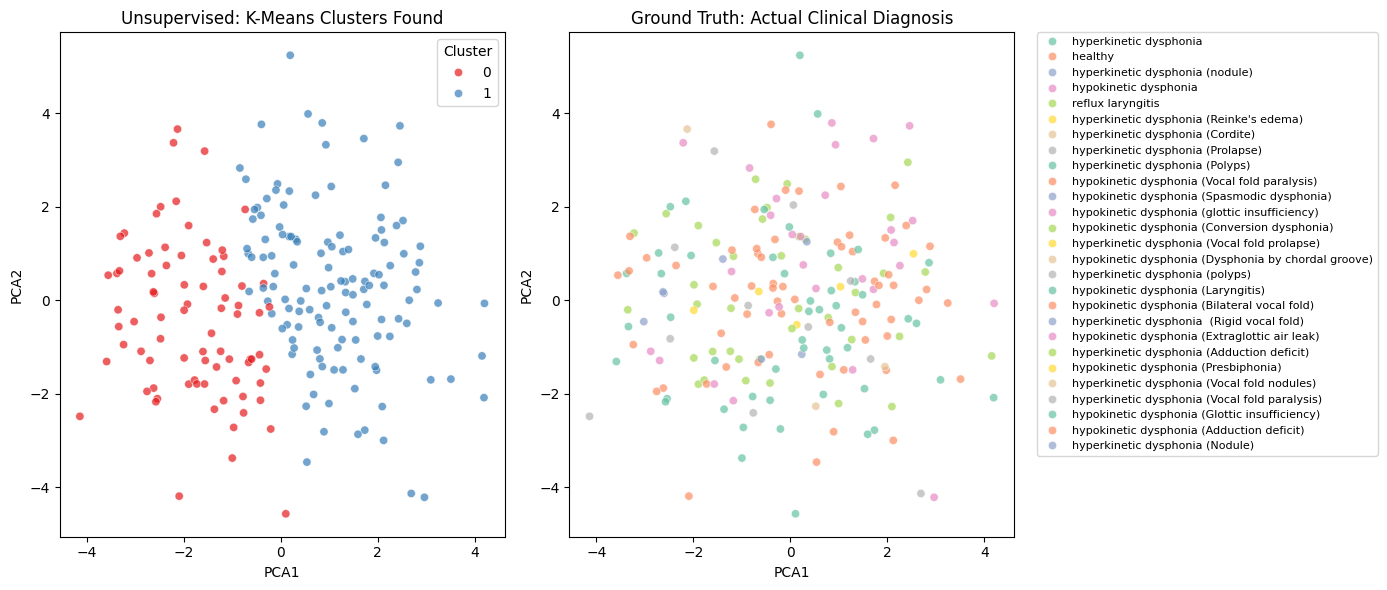


Cross-tabulation of AI Clusters vs Actual Disease Status:


"True Label (0=Healthy, 1=Sick)",0,1
AI Cluster,,
0,19,61
1,38,90


In [12]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Scale the FULL dataset (since clustering needs all the data, not just a training chunk)
X_full_scaled = scaler.fit_transform(X)

# 2. Run K-Means Clustering to find 2 natural groups
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_final['Cluster'] = kmeans.fit_predict(X_full_scaled)

# 3. Reduce our 16+ features down to 2 dimensions for visual plotting
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_full_scaled)

df_final['PCA1'] = principal_components[:, 0]
df_final['PCA2'] = principal_components[:, 1]

# 4. Plot the results using Seaborn
plt.figure(figsize=(14, 6))

# Plot A: What the Machine Learning model discovered (Clusters)
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Cluster', 
    palette='Set1', 
    data=df_final, 
    alpha=0.7
)
plt.title("Unsupervised: K-Means Clusters Found")

# Plot B: What the Ground Truth Diagnosis Actually Was
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Diagnosis', 
    palette='Set2', 
    data=df_final, 
    alpha=0.7
)
# Make legend smaller and place outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8) 
plt.title("Ground Truth: Actual Clinical Diagnosis")

plt.tight_layout()
plt.show()

# Quick text analysis: Did Cluster 0 mostly capture healthy people, and Cluster 1 pathological? 
cluster_crosstab = pd.crosstab(df_final['Cluster'], df_final['Label'], 
                               rownames=['AI Cluster'], colnames=['True Label (0=Healthy, 1=Sick)'])
print("\nCross-tabulation of AI Clusters vs Actual Disease Status:")
cluster_crosstab

### Phase 5: Draft Preparation & Conclusion

We have now written, executed, and tested the code required to fulfill:
- The data preprocessing requirements.
- Problem #1 (Supervised ML testing 5 algorithms and reporting specific metrics like Accuracy, Sensitivity, Specificity, F1).
- Problem #2 (Unsupervised ML via K-Means and cross-tabulation with actual diagnoses).

**The Final Step** is assembling this data into your required 6-page IEEE JBHI format report.

As a reminder, your report must include:
1. **Title and Abstract**
2. **Introduction**
3. **Methods** (Mention Librosa feature extraction, StandardScaler, the 80/20 split, and the 5 specific models used)
4. **Results** (Insert the table we generated in Step 3.2, and the cluster graphs from Step 4.1)
5. **Discussion/Conclusion**
6. **References**

The coding portion of this mini-project is complete. You can rerun this notebook anytime, and you can tweak hyperparameters (like `n_neighbors=5` in KNN or `n_clusters=2` in KMeans) to see if you can get even better results for your final report!